# <center> UE23CS342AA2 - Data Analytics</center>

# <center> Worksheet 4a: Building a Movie Recommender System </center>

<center> Designed by Motamarri Sai Sathvik, Sruthi Sivakumar & Rishi Gupta PESU-26 </center>

<br>

- Student name: Krishank Kureti
- SRN: PES2UG23CS285
- Section:'E'

## Introduction

Imagine you're a data scientist at a new movie streaming startup, "CineStream". To compete with established giants, CineStream needs to provide excellent, personalized movie recommendations to its users. Your task is to build and analyze a collaborative filtering recommender system using a dataset of user ratings.

### Details of the dataset (MovieLens `ml-latest-small`):

This dataset contains ~100,000 ratings applied to ~9,000 movies by ~600 users.

We will use two files:
-   **`ratings.csv`**: Contains `userId`, `movieId`, `rating` (on a 5-star scale), and `timestamp`.
-   **`movies.csv`**: Contains `movieId`, `title`, and `genres`.

### Core Concepts:

*   **Utility Matrix**: An `m x n` matrix where `m` is the number of users and `n` is the number of items (movies). Each cell `(i, j)` contains the rating user `i` gave to item `j`. This matrix is typically very *sparse* because a user has only rated a small fraction of all available movies.
*   **Collaborative Filtering (CF)**: A technique that makes predictions (filters) about the interests of a user by collecting preferences or taste information from many other users (collaborating). The underlying assumption is that if person A has the same opinion as person B on an issue, A is more likely to have B's opinion on a different issue than that of a randomly chosen person.
    *   **User-Based CF**: Recommends items by finding users who are similar to the target user. It then suggests items that the similar users liked but the target user has not yet seen.
    *   **Item-Based CF**: Recommends items by finding items that are similar to the ones the target user has rated highly. It then suggests those similar items.

## 1. Setup: Install and Load Packages

First, we need to install the necessary libraries.

In [1]:
# Install the necessary libraries using the following command:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

## 2. Load and Explore the Data

*Ensure to load and merge `movies.csv` and `ratings.csv` on the movieID.*

Merged Dataset Preview:
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId 

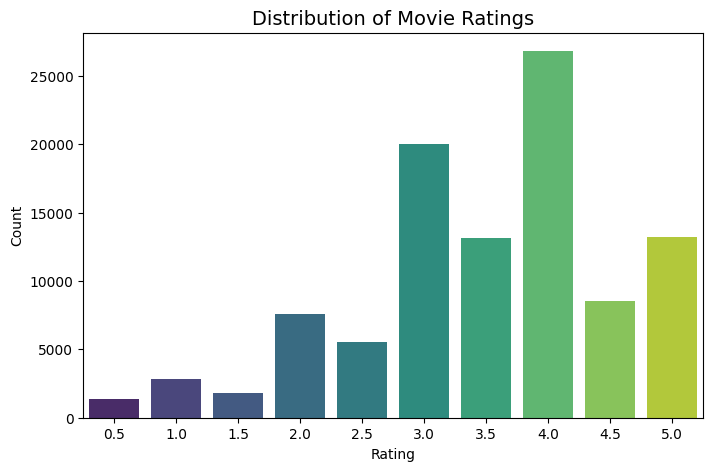

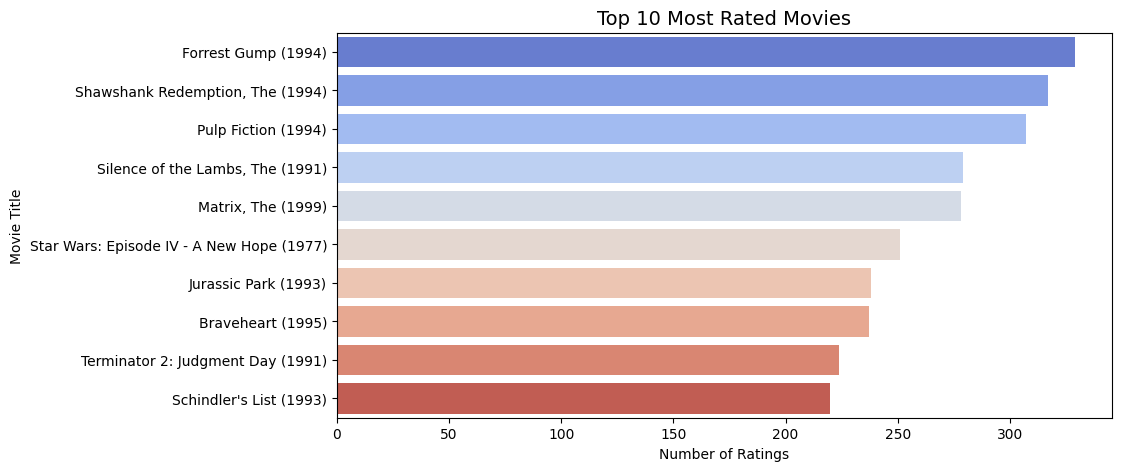

In [14]:
# Load the datasets
ratings = pd.read_csv('/kaggle/input/collaborative-filtering-recommnder-system-dataset/ratings.csv')
movies = pd.read_csv('/kaggle/input/collaborative-filtering-recommnder-system-dataset/movies.csv')
movie_data = pd.merge(ratings, movies, on='movieId')
print("Merged Dataset Preview:")
print(movie_data.head())
print("\nDataset Info:")
print(movie_data.info())
print("\nMissing Values:")
print(movie_data.isnull().sum())
print("\nRatings Statistics:")
print(movie_data['rating'].describe())
num_users = movie_data['userId'].nunique()
num_movies = movie_data['movieId'].nunique()

print(f"\nNumber of unique users: {num_users}")
print(f"Number of unique movies: {num_movies}")
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=movie_data, palette='viridis')
plt.title('Distribution of Movie Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

top_movies = movie_data['title'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_movies.values, y=top_movies.index, palette='coolwarm')
plt.title('Top 10 Most Rated Movies', fontsize=14)
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()

## 3. EDA and Preprocessing

**(1 point)**

Perform some initial exploratory data analysis (EDA). State at least two observations you made. Feel free to remove any columns you think are not necessary.

**Hints:**
*   Check the `head()`, `info()`, and `describe()` of the data.
*   Check for null values or duplicates.
*   To reduce computation time for this exercise, you can filter the dataset to include only users who have rated at least 50 movies and movies that have been rated at least 50 times.
*   Create a utility matrix (users as rows, movie titles as columns, ratings as values).

In [15]:
filtered_data = movie_data.drop(columns=['timestamp'])

filtered_data = filtered_data.groupby('userId').filter(lambda x: len(x) >= 50)
filtered_data = filtered_data.groupby('movieId').filter(lambda x: len(x) >= 50)
print("Head of filtered data:")
print(filtered_data.head())

print("\nInfo:")
print(filtered_data.info())

print("\nDescribe:")
print(filtered_data.describe())

print("\nMissing Values:")
print(filtered_data.isnull().sum())
print("\nDuplicates:", filtered_data.duplicated().sum())
utility_matrix = filtered_data.pivot_table(index='userId', columns='title', values='rating')
print("\nUtility Matrix Shape:", utility_matrix.shape)

Head of filtered data:
   userId  movieId  rating                        title  \
0       1        1     4.0             Toy Story (1995)   
2       1        6     4.0                  Heat (1995)   
3       1       47     5.0  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0   Usual Suspects, The (1995)   
5       1       70     3.0   From Dusk Till Dawn (1996)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  
5                Action|Comedy|Horror|Thriller  

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 35213 entries, 0 to 100701
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   userId   35213 non-null  int64  
 1   movieId  35213 non-null  int64  
 2   rating   35213 non-null  float64
 3   title    35213 non-nul

Observations:
1. Removed 'timestamp' column as it is not required for collaborative filtering.
2. After filtering, only users and movies with at least 50 ratings remain, reducing sparsity.
3. Ratings mostly range from 3 to 4, indicating generally positive feedback.

## Problem 1: User-Based Collaborative Filtering

**(3 points: 2 for implementation, 1 for explanation)**

1.  Your task is to find movie recommendations for a specific user whose **`userId = 1`**. Recommend the top 5 movies for this user based on the tastes of similar users.
2.  Which similarity metric did you use (e.g., Cosine, Pearson, Euclidean)? Explain why it is a suitable choice for this problem.

**Hint:**
*   You can use `scipy.spatial.distance.cosine` or `sklearn.metrics.pairwise.cosine_similarity`. Remember that distance = 1 - similarity.
*   Remeber to Normalize the utility matrix (subtracting the mean rating of each user).
*   You can first try to find the most similar users to user; keep in mind to exclude the user themselves while doing this.
*   Exclude movies the user has already seen.

In [16]:
user_mean = utility_matrix.mean(axis=1)
utility_matrix_norm = utility_matrix.sub(user_mean, axis=0).fillna(0)
user_similarity = pd.DataFrame(cosine_similarity(utility_matrix_norm),
                               index=utility_matrix_norm.index,
                               columns=utility_matrix_norm.index)
target_user = 1
similar_users = user_similarity[target_user].drop(index=target_user)
similar_users = similar_users.sort_values(ascending=False)
top_similar_users = similar_users.head(10)

user_rated_movies = utility_matrix.loc[target_user]
user_rated_movies = user_rated_movies[user_rated_movies.notna()].index
predicted_ratings = {}
for movie in utility_matrix.columns:
    if movie not in user_rated_movies:
        num = 0
        den = 0
        for sim_user, sim_score in top_similar_users.items():
            rating = utility_matrix.loc[sim_user, movie]
            if not np.isnan(rating):
                num += sim_score * (rating - user_mean[sim_user])
                den += abs(sim_score)
        if den != 0:
            predicted_ratings[movie] = user_mean[target_user] + (num / den)
top_5_recommendations = sorted(predicted_ratings.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Movie Recommendations for User 1:")
for i, (movie, rating) in enumerate(top_5_recommendations, 1):
    print(f"{i}. {movie} — Predicted Rating: {rating:.2f}")

Top 5 Movie Recommendations for User 1:
1. No Country for Old Men (2007) — Predicted Rating: 5.96
2. Godfather, The (1972) — Predicted Rating: 5.71
3. Exorcist, The (1973) — Predicted Rating: 5.62
4. Casablanca (1942) — Predicted Rating: 5.61
5. Donnie Darko (2001) — Predicted Rating: 5.58


## Problem 2: Predicting a Rating

**(1 point)**

Continuing with **`userId = 1`**, predict the rating they would likely give to the top recommended movie from the previous problem.

**Hint:** The predicted rating for a user `u` on an item `i` can be calculated as a weighted average of the ratings given by similar users `v` to that same item `i`.
`PredictedRating(u, i) = sum(similarity(u, v) * rating(v, i)) / sum(similarity(u, v))` for all similar users `v` who have rated item `i`.

In [17]:
top_movie = top_5_recommendations[0][0]
rated_by = utility_matrix[top_movie].dropna().index
sim_scores = similar_users[rated_by]
ratings = utility_matrix.loc[rated_by, top_movie]
predicted_rating = np.dot(sim_scores, ratings) / sim_scores.sum()
print(f"Predicted rating for userId = 1 on '{top_movie}': {predicted_rating:.2f}")

Predicted rating for userId = 1 on 'No Country for Old Men (2007)': 4.12


## Problem 3: Item-Based Collaborative Filtering

**(2 points)**

Now, use an **item-based** approach to recommend the top 5 movies for a different user, **`userId = 15`**. Implement this using pandas and sklearn's cosine similarity.

**A Breakdown on how to approach this problem:**
*   **Step 1: Reshape Your Data.** To compare movies with each other (item-item), you need a matrix where movies are rows and users are columns. Your current `utility_matrix` is likely `users x movies`. How can you flip it? (Hint: pandas has a very simple way to do this).

*   **Step 2: Calculate Item-Item Similarity.** The `cosine_similarity` function cannot handle `NaN` (missing) values. You must first replace them with a number. A common and simple strategy is to fill them with `0`. After calculating the similarity, it's best to put the results back into a new DataFrame with movie titles as both the index and columns for easy lookups later.

*   **Step 3: Isolate Target User's Data.** You need to identify two key groups of movies for your target user (`userId = 15`):
    1.  The movies they **have** rated (and the scores they gave them). You will use these ratings to make predictions.
    2.  The movies they **have not** rated. These are your candidates for recommendation.

*   **Step 4: Predict Ratings Using a Weighted Average.** This is the core of the algorithm. For each movie the user **hasn't** seen, you will predict a score. 


    For each candidate movie `M`:
    *   Initialize a `numerator` and a `denominator` to zero.
    *   Loop through every movie `R` that the user **has** rated.
    *   Find the similarity between `M` and `R` from your similarity matrix.
    *   Update the numerator: `numerator += similarity * (user's rating for R)`
    *   Update the denominator: `denominator += similarity`
    *   After the loop, the predicted rating is `numerator / denominator`. (Make sure the denominator is not zero!)

*   **Step 5: Rank and Recommend.** Once you have calculated a predicted rating for all unseen movies, sort them from highest to lowest to find the top 5.

In [18]:
item_matrix = utility_matrix.T
item_matrix_filled = item_matrix.fillna(0)
item_similarity = cosine_similarity(item_matrix_filled)
item_similarity_df = pd.DataFrame(item_similarity, index=item_matrix.index, columns=item_matrix.index)
target_user = 15
user_ratings = utility_matrix.loc[target_user]

rated_movies = user_ratings[user_ratings.notna()]
unrated_movies = user_ratings[user_ratings.isna()]

predicted_ratings_item = {}
for movie in unrated_movies.index:
    numerator = 0
    denominator = 0
    for rated_movie, rating in rated_movies.items():
        sim = item_similarity_df.loc[movie, rated_movie]
        numerator += sim * rating
        denominator += abs(sim)
    if denominator != 0:
        predicted_ratings_item[movie] = numerator / denominator
top_5_item_based = sorted(predicted_ratings_item.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Movie Recommendations for User 15:")
for i, (movie, rating) in enumerate(top_5_item_based, 1):
    print(f"{i}. {movie} — Predicted Rating: {rating:.2f}")

Top 5 Movie Recommendations for User 15:
1. Butch Cassidy and the Sundance Kid (1969) — Predicted Rating: 3.84
2. Leaving Las Vegas (1995) — Predicted Rating: 3.82
3. Piano, The (1993) — Predicted Rating: 3.82
4. Star Trek II: The Wrath of Khan (1982) — Predicted Rating: 3.81
5. Dead Man Walking (1995) — Predicted Rating: 3.81


## Problem 4: The Long-Tail Problem

**(2 points)**

1.  Plot a graph showing the number of ratings for each movie, sorted in descending order. What does this graph tell you about the distribution of ratings in the dataset? This phenomenon is known as the "long-tail".
2.  Briefly explain the "long-tail problem" in recommender systems and suggest one way to help mitigate it.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


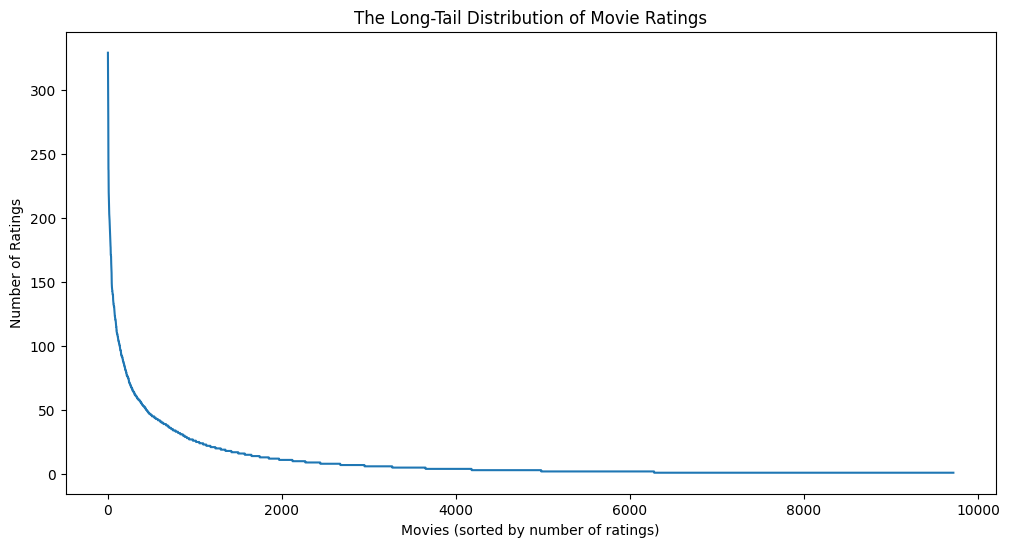

Explanation:
The graph shows that a small number of movies receive a large number of ratings,
while most movies receive very few ratings — forming a 'long tail'.
This is the 'long-tail problem' in recommender systems: popular items dominate,
while niche movies rarely get enough data to be recommended accurately.

One way to mitigate this is by combining collaborative filtering with content-based filtering,
so even less-rated movies can be recommended based on their attributes or genres.


In [19]:
movie_rating_counts = movie_data['title'].value_counts()

plt.figure(figsize=(12,6))
sns.lineplot(x=range(len(movie_rating_counts)), y=movie_rating_counts.values)
plt.title('The Long-Tail Distribution of Movie Ratings')
plt.xlabel('Movies (sorted by number of ratings)')
plt.ylabel('Number of Ratings')
plt.show()

print("Explanation:")
print("The graph shows that a small number of movies receive a large number of ratings,")
print("while most movies receive very few ratings — forming a 'long tail'.")
print("This is the 'long-tail problem' in recommender systems: popular items dominate,")
print("while niche movies rarely get enough data to be recommended accurately.")
print("\nOne way to mitigate this is by combining collaborative filtering with content-based filtering,")
print("so even less-rated movies can be recommended based on their attributes or genres.")

## Problem 5: Shortcomings and Next Steps

**(1 point)**

Based on your analysis, what is a key shortcoming of the collaborative filtering approach you used? What is one modification or alternative approach you could explore to potentially achieve better or more diverse recommendations?

Collaborative filtering works well, but it struggles when the data is too sparse or when users haven’t rated enough things, it ends up recommending the same popular movies over and over. New movies or new users basically get ignored because the model has nothing to work with. A possible next step could be mixing in content-based features so the system can at least understand what a movie is, not just who rated it, which might lead to more variety and fewer repetitive suggestions.

Kudos on completing the task! Hope you could learn a few new things along the way.